In [1]:
%load_ext autoreload
%autoreload 2
from utils.plotting import *
from results.results import *

In [2]:
# LOOKING FOR FOLDERS

# filter all folder name in rel_path = "/home/khain/FSNet/results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000" that contain "finetune_20251030-232939_model_20"

rel_path = "/home/khain/FSNet/results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000"
dir_path_seeds = []
for folder_name in os.listdir(rel_path):
    if "finetune_20251101-002602" in folder_name:
        dir_path_seeds.append(os.path.join(folder_name))

# print line by line dir_path_seeds
for path in dir_path_seeds:
    print(f"\"{path}\",")

"20251101-004609_MLP_FSNet_seed0_dropout0.1_finetune_20251101-002602_model_20",
"20251101-012021_MLP_FSNet_seed1_dropout0.1_finetune_20251101-002602_model_20",
"20251101-015622_MLP_FSNet_seed2_dropout0.1_finetune_20251101-002602_model_20",
"20251101-023133_MLP_FSNet_seed3_dropout0.1_finetune_20251101-002602_model_20",
"20251101-030629_MLP_FSNet_seed0_dropout0.1_finetune_20251101-002602_model_60",
"20251101-034907_MLP_FSNet_seed1_dropout0.1_finetune_20251101-002602_model_60",
"20251101-042726_MLP_FSNet_seed2_dropout0.1_finetune_20251101-002602_model_60",
"20251101-050812_MLP_FSNet_seed3_dropout0.1_finetune_20251101-002602_model_60",


In [27]:
# Getting results
rel_path = "/home/khain/FSNet/results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000"
# dir_path_seeds = fsnet_ft_ckpt20_subopt00_over_train_size
# dir_path_seeds = fsnet_ft_ckpt20_train_size7000_over_subopt
dir_path_seeds = fsnet_ft_subopt100_train_size7000_over_ckpt
# dir_path_seeds = fsnet_ft_subopt40_train_size7000_over_ckpt
# dir_path_seeds = fsnet_ft_subopt20_train_size7000_over_ckpt
# dir_path_seeds = fsnet_ft_subopt10_train_size7000_over_ckpt
# dir_path_seeds = fsnet_ft_subopt05_train_size7000_over_ckpt
# dir_path_seeds = fsnet_ft_subopt00_train_size7000_over_ckpt

'objective', 'true_objective',
'opt_gap_mean', 'opt_gap_std', 'opt_gap_max', 'opt_gap_min',
'eq_violation_l2_mean', 'eq_violation_l2_max',
'ineq_violation_l2_mean', 'ineq_violation_l2_max',
'eq_violation_l1_mean', 'eq_violation_l1_max',
'ineq_violation_l1_mean', 'ineq_violation_l1_max',
'eq_violation_max_mean', 'eq_violation_max_max',
'ineq_violation_max_mean', 'ineq_violation_max_max',
'solution_distance_mean', 'solution_distance_std', 'solution_distance_max'

In [28]:
opt_gap_mean = np.zeros_like(dir_path_seeds, dtype=float)
opt_gap_max = np.zeros_like(dir_path_seeds, dtype=float)
opt_gap_std = np.zeros_like(dir_path_seeds, dtype=float)
eq_violation_l1_mean = np.zeros_like(dir_path_seeds, dtype=float)
eq_violation_l1_max = np.zeros_like(dir_path_seeds, dtype=float)
ineq_violation_l1_mean = np.zeros_like(dir_path_seeds, dtype=float)
ineq_violation_l1_max = np.zeros_like(dir_path_seeds, dtype=float)

batch_size = 256
for i in range(dir_path_seeds.shape[0]):  # over ckpt
    for j in range(dir_path_seeds.shape[1]):  # over seeds
        dir_path = os.path.join(
            rel_path, dir_path_seeds[i, j]
        )
        with open(os.path.join(dir_path, "results.pkl"), "rb") as f:
            results = pickle.load(f)
            results_ = results['test_results']['batch_size_comparison'][batch_size]['metrics']
        opt_gap_mean[i, j] = results_["opt_gap_mean"]
        opt_gap_max[i, j] = results_["opt_gap_max"]
        opt_gap_std[i, j] = results_["opt_gap_std"]
        eq_violation_l1_mean[i, j] = results_["eq_violation_l1_mean"]
        eq_violation_l1_max[i, j] = results_["eq_violation_l1_max"]
        ineq_violation_l1_mean[i, j] = results_["ineq_violation_l1_mean"]
        ineq_violation_l1_max[i, j] = results_["ineq_violation_l1_max"]

In [29]:
# assuming you already have: dir_path_seeds, rel_path
num_baselines = dir_path_seeds.shape[0]
num_seeds = dir_path_seeds.shape[1]
print(num_baselines, num_seeds)

# read one file to know number of epochs
with open(os.path.join(rel_path, dir_path_seeds[0, 0], "results.pkl"), "rb") as f:
    results = pickle.load(f)
    num_epochs = len(results["val_history"])

# store [num_baselines, num_seeds, num_epochs]
opt_gap_mean_epochs = np.zeros((num_baselines, num_seeds, num_epochs))

for i in range(num_baselines):  # over ckpt
    for j in range(num_seeds):  # over seed
        dir_path = os.path.join(rel_path, dir_path_seeds[i, j])
        with open(os.path.join(dir_path, "results.pkl"), "rb") as f:
            results = pickle.load(f)
            results_ = results["val_history"]
            opt_gap_mean_epochs[i, j, :] = [r["opt_gap_mean"] for r in results_]

3 4


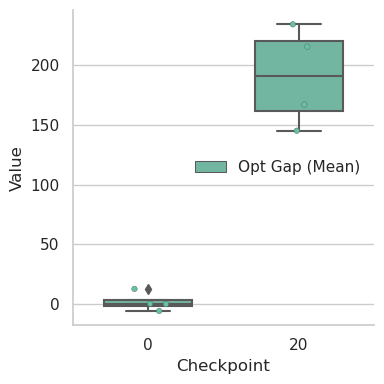

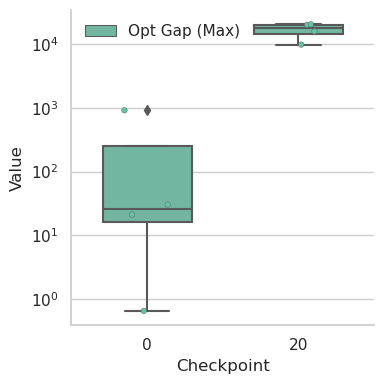

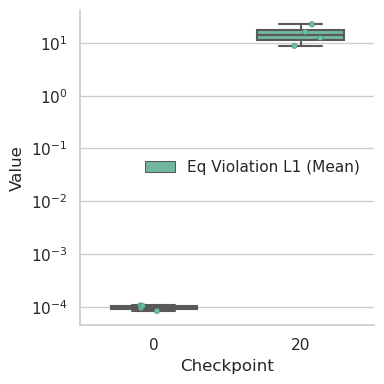

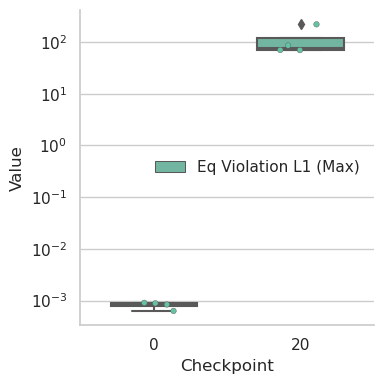

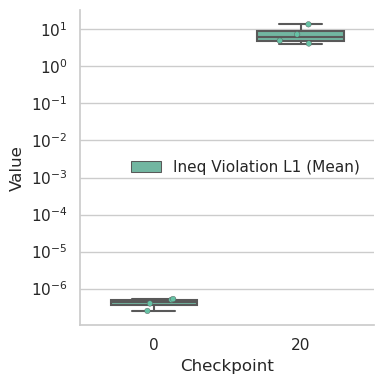

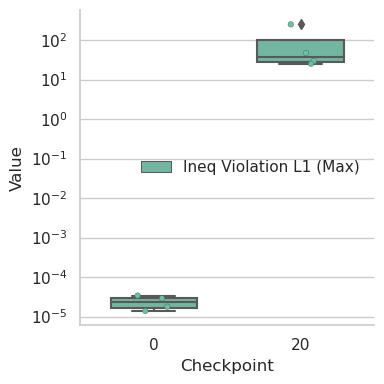

In [30]:
checkpoints = np.array([0, 20])

plot_box_with_points(
    [opt_gap_mean],
    ["Opt Gap (Mean)"],
    checkpoints,
    x_label="Checkpoint",
    title="",
    log_scale_y=False,
    figsize=(4, 4),
)

plot_box_with_points(
    [opt_gap_max],
    ["Opt Gap (Max)"],
    checkpoints,
    x_label="Checkpoint",
    title="",
    log_scale_y=True,
    figsize=(4, 4),
)

plot_box_with_points(
    [eq_violation_l1_mean],
    ["Eq Violation L1 (Mean)"],
    checkpoints,
    x_label="Checkpoint",
    title="",
    log_scale_y=True,
    figsize=(4, 4),
)

plot_box_with_points(
    [eq_violation_l1_max],
    ["Eq Violation L1 (Max)"],
    checkpoints,
    x_label="Checkpoint",
    title="",
    log_scale_y=True,
    figsize=(4, 4),
)

plot_box_with_points(
    [ineq_violation_l1_mean],
    ["Ineq Violation L1 (Mean)"],
    checkpoints,
    x_label="Checkpoint",
    title="",
    log_scale_y=True,
    figsize=(4, 4),
)

plot_box_with_points(
    [ineq_violation_l1_max],
    ["Ineq Violation L1 (Max)"],
    checkpoints,
    x_label="Checkpoint",
    title="",
    log_scale_y=True,
    figsize=(4, 4),
)

In [ ]:
plot_metric_over_epochs(
    metric_array=opt_gap_mean_epochs,   # shape [num_ckpts, num_seeds, num_epochs]
    baselines=checkpoints,
    metric_name="Opt Gap (Mean)",
    # title="Validation Opt Gap Mean per Checkpoint",
    log_scale_y=True,        # set False if values are small
    epochs_per_val=20,
    colors="tab10",
)

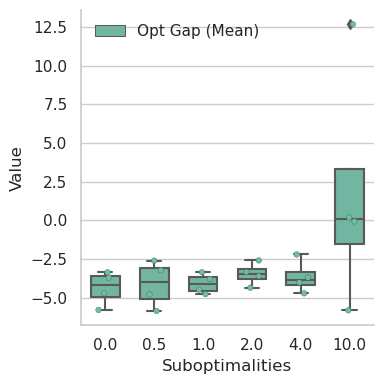

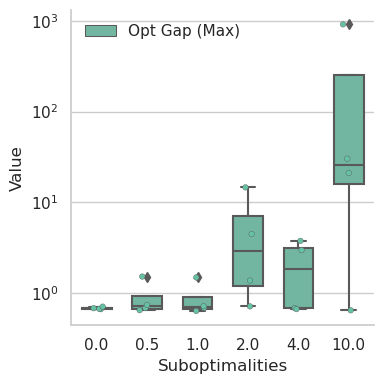

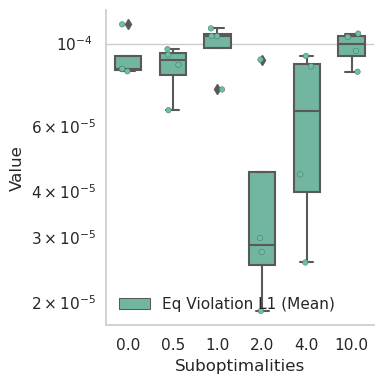

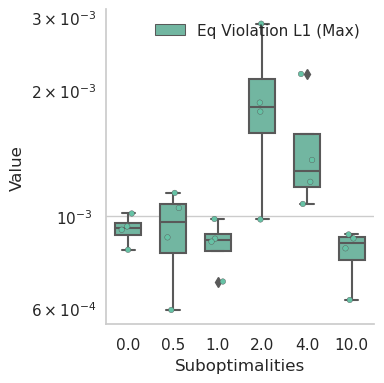

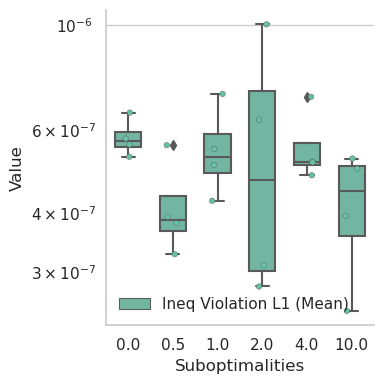

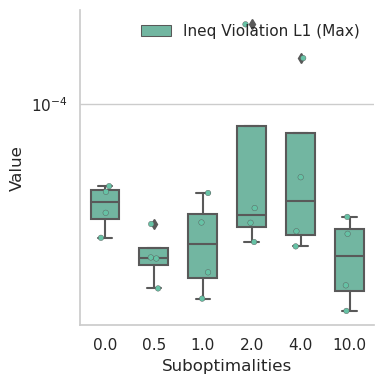

In [9]:
# PLOTS FOR DIFFERENT SUBOPTIMALITIES

suboptimalities = np.array([0, 0.5, 1.0, 2.0, 4.0, 10.0])

plot_box_with_points(
    [opt_gap_mean],
    ["Opt Gap (Mean)"],
    suboptimalities,
    x_label="Suboptimalities",
    title="",
    log_scale_y=False,
    figsize=(4, 4),
)

plot_box_with_points(
    [opt_gap_max],
    ["Opt Gap (Max)"],
    suboptimalities,
    x_label="Suboptimalities",
    title="",
    log_scale_y=True,
    figsize=(4, 4),
)

plot_box_with_points(
    [eq_violation_l1_mean],
    ["Eq Violation L1 (Mean)"],
    suboptimalities,
    x_label="Suboptimalities",
    title="",
    log_scale_y=True,
    figsize=(4, 4),
)

plot_box_with_points(
    [eq_violation_l1_max],
    ["Eq Violation L1 (Max)"],
    suboptimalities,
    x_label="Suboptimalities",
    title="",
    log_scale_y=True,
    figsize=(4, 4),
)

plot_box_with_points(
    [ineq_violation_l1_mean],
    ["Ineq Violation L1 (Mean)"],
    suboptimalities,
    x_label="Suboptimalities",
    title="",
    log_scale_y=True,
    figsize=(4, 4),
)

plot_box_with_points(
    [ineq_violation_l1_max],
    ["Ineq Violation L1 (Max)"],
    suboptimalities,
    x_label="Suboptimalities",
    title="",
    log_scale_y=True,
    figsize=(4, 4),
)

In [ ]:
plot_metric_over_epochs(
    metric_array=opt_gap_mean_epochs,   # shape [num_ckpts, num_seeds, num_epochs]
    baselines=suboptimalities,
    metric_name="Opt Gap (Mean)",
    # title="Validation Opt Gap Mean per Checkpoint",
    log_scale_y=True,        # set False if values are small
    epochs_per_val=20,
    colors="tab10",
)

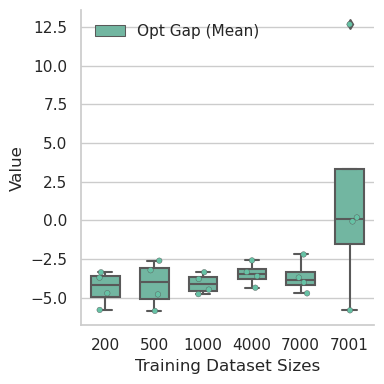

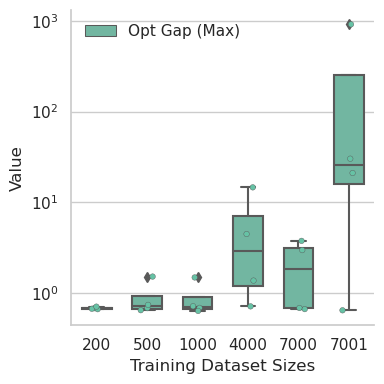

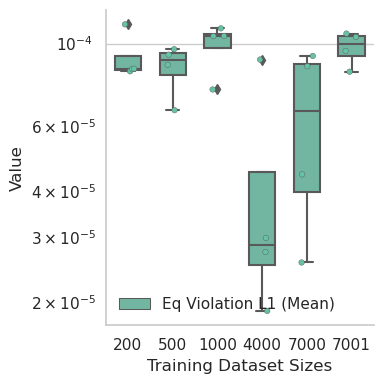

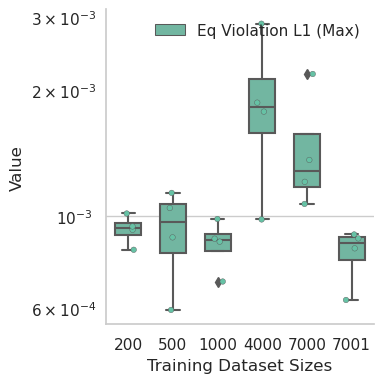

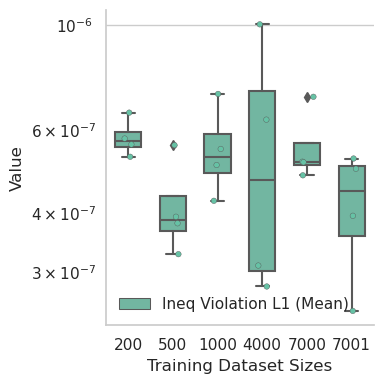

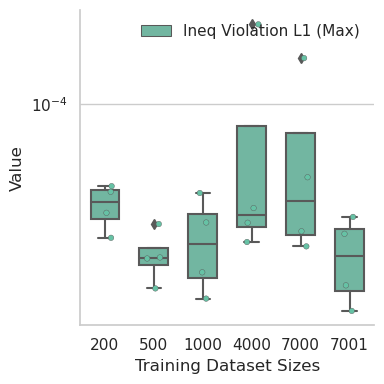

In [10]:
# PLOTS FOR DIFFERENT TRAINING DATASET SIZES

train_sizes = np.array([200, 500, 1000, 4000, 7000, 7001])

plot_box_with_points(
    [opt_gap_mean],
    ["Opt Gap (Mean)"],
    train_sizes,
    x_label="Training Dataset Sizes",
    title="",
    log_scale_y=False,
    figsize=(4, 4),
)

plot_box_with_points(
    [opt_gap_max],
    ["Opt Gap (Max)"],
    train_sizes,
    x_label="Training Dataset Sizes",
    title="",
    log_scale_y=True,
    figsize=(4, 4),
)

plot_box_with_points(
    [eq_violation_l1_mean],
    ["Eq Violation L1 (Mean)"],
    train_sizes,
    x_label="Training Dataset Sizes",
    title="",
    log_scale_y=True,
    figsize=(4, 4),
)

plot_box_with_points(
    [eq_violation_l1_max],
    ["Eq Violation L1 (Max)"],
    train_sizes,
    x_label="Training Dataset Sizes",
    title="",
    log_scale_y=True,
    figsize=(4, 4),
)

plot_box_with_points(
    [ineq_violation_l1_mean],
    ["Ineq Violation L1 (Mean)"],
    train_sizes,
    x_label="Training Dataset Sizes",
    title="",
    log_scale_y=True,
    figsize=(4, 4),
)

plot_box_with_points(
    [ineq_violation_l1_max],
    ["Ineq Violation L1 (Max)"],
    train_sizes,
    x_label="Training Dataset Sizes",
    title="",
    log_scale_y=True,
    figsize=(4, 4),
)

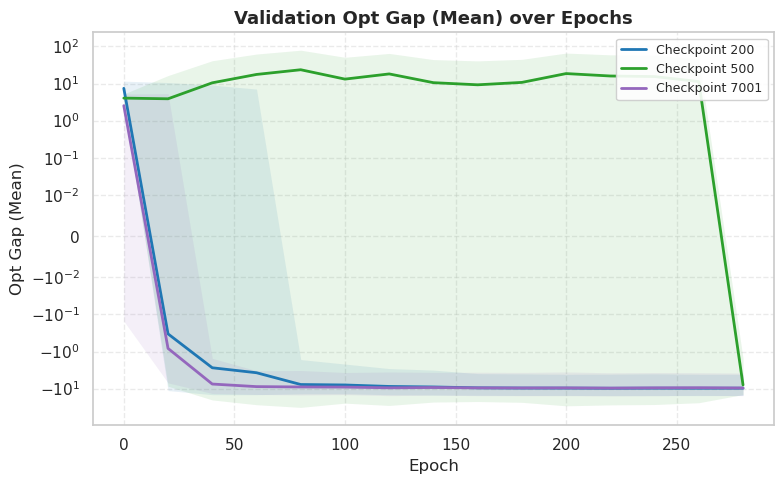

In [21]:
plot_metric_over_epochs(
    metric_array=opt_gap_mean_epochs,   # shape [num_ckpts, num_seeds, num_epochs]
    baselines=train_sizes[[0, 1, 5]],
    metric_name="Opt Gap (Mean)",
    # title="Validation Opt Gap Mean per Checkpoint",
    log_scale_y=True,        # set False if values are small
    epochs_per_val=20,
    colors="tab10",
)